# 06  -  Domain Adaptation

DANN + Subdomain Adaptation + HEN across all 6 cross-domain transfer scenarios.

**Inputs:** `outputs/*_features.csv`  
**Outputs:** `outputs/domain_adaptation_results.csv`

In [1]:
exec(open('00_config.py').read())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, roc_auc_score, precision_score,
                              recall_score, matthews_corrcoef,
                              precision_recall_curve, auc as sklearn_auc)
from imblearn.over_sampling import SMOTE

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

cc = pd.read_csv(CC_FEATURES_CSV)
mm = pd.read_csv(MM_FEATURES_CSV)
hi = pd.read_csv(HI_FEATURES_CSV)

def get_Xy(df):
    X = df.drop(columns=[TARGET_COL]).select_dtypes(include=np.number).fillna(0)
    return X.values.astype(np.float32), df[TARGET_COL].values.astype(np.float32)

cc_X, cc_y = get_Xy(cc)
mm_X, mm_y = get_Xy(mm)
hi_X, hi_y = get_Xy(hi)

# Subsample CC and MM so SMOTE + DANN training stays tractable
MAX_SOURCE = 200_000

def subsample(X, y, max_n=MAX_SOURCE, seed=42):
    if len(X) <= max_n:
        return X, y
    rng  = np.random.default_rng(seed)
    fi   = np.where(y == 1)[0]
    ni   = np.where(y == 0)[0]
    rate = len(fi) / len(y)
    nf   = min(int(max_n * rate), len(fi))
    nn_  = min(max_n - nf, len(ni))
    idx  = np.concatenate([rng.choice(fi, nf, replace=False), rng.choice(ni, nn_, replace=False)])
    rng.shuffle(idx)
    return X[idx], y[idx]

cc_X, cc_y = subsample(cc_X, cc_y)
mm_X, mm_y = subsample(mm_X, mm_y)
print(f'CC:{cc_X.shape}  MM:{mm_X.shape}  HI:{hi_X.shape}')

Config loaded. BASE_DIR: /home/compute.ashesi.lan/sedem.agudetse/UniFraud-GH
Config loaded. BASE_DIR: /home/compute.ashesi.lan/sedem.agudetse/UniFraud-GH
Device: cuda
CC:(200000, 14)  MM:(200000, 9)  HI:(2655, 25)


## Helpers

In [2]:
def find_best_threshold_mcc(probs, y_true):
    best_t, best_s = 0.5, -1
    for t in np.arange(0.01, 0.99, 0.005):
        preds = (probs >= t).astype(int)
        try:
            s = matthews_corrcoef(y_true, preds)
        except Exception:
            s = -1
        if s > best_s:
            best_s, best_t = s, t
    return best_t, best_s

def find_best_threshold_f1(probs, y_true):
    best_t, best_s = 0.5, 0
    for t in np.arange(0.01, 0.99, 0.005):
        s = f1_score(y_true, (probs >= t).astype(int), zero_division=0)
        if s > best_s:
            best_s, best_t = s, t
    return best_t, best_s

def smart_threshold(probs, y_true):
    if y_true.mean() < 0.05:
        return find_best_threshold_mcc(probs, y_true)[0], 'MCC'
    return find_best_threshold_f1(probs, y_true)[0], 'F1'

def maybe_smote(X, y, target=0.10):
    rate = y.mean()
    if rate >= target:
        return X, y
    desired = 0.05 if rate < 0.01 else 0.10 if rate < 0.05 else target
    k = min(5, int(y.sum()) - 1)
    if k < 1:
        return X, y
    sm = SMOTE(sampling_strategy=desired, random_state=RANDOM_STATE, k_neighbors=k)
    X_r, y_r = sm.fit_resample(X, y)
    print(f'  SMOTE: {len(X):,} -> {len(X_r):,}  fraud {y_r.mean():.2%}')
    return X_r, y_r

def compute_pos_weight(y):
    n_neg = (y == 0).sum()
    n_pos = (y == 1).sum()
    return torch.tensor(n_neg / n_pos if n_pos > 0 else 1.0, dtype=torch.float32)

def full_evaluate(y_true, y_pred, probs, src, tgt, method):
    m = {
        'method': method, 'source': src, 'target': tgt,
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'mcc':       matthews_corrcoef(y_true, y_pred),
    }
    try:
        m['roc_auc'] = roc_auc_score(y_true, probs)
        prec, rec, _ = precision_recall_curve(y_true, probs)
        m['pr_auc']  = sklearn_auc(rec, prec)
    except Exception:
        m['roc_auc'] = m['pr_auc'] = 0.0
    print(f'  -> F1={m["f1"]:.4f} MCC={m["mcc"]:.4f} AUC={m["roc_auc"]:.4f}')
    return m

print('Helpers defined')

Helpers defined


## Semantic Feature Alignment

In [3]:
# Maps domain-specific column names to three universal fraud concepts.
# This lets us align CC geo_distance to MM balance_error under
# the shared 'Structural Distance' concept rather than truncating by position.
SEMANTIC_GROUPS = {
    'Credit Card': {
        'amount_anomaly':      ['amount_zscore','amount_deviation','is_large','is_micro','amt_ghs','is_high_value','amount_is_round','amt'],
        'counterparty_risk':   ['category','merchant','high_risk_cat','high_risk_merch'],
        'structural_distance': ['geo_distance','long_distance','is_rural','unusual_timing','tx_burst','rapid_succession'],
    },
    'Mobile Money': {
        'amount_anomaly':      ['amount_zscore','amount_deviation','is_large','is_micro','is_high_value','amount'],
        'counterparty_risk':   ['recipient','oldBal','newBal','balance_zeroed','is_agent'],
        'structural_distance': ['balance_error','balance_diff','unusual_timing','tx_burst','rapid_succession'],
    },
    'Health Insurance': {
        'amount_anomaly':      ['amount_zscore','amount_deviation','is_large','is_micro','dev_total','dev_service','dev_medical','max_deviation'],
        'counterparty_risk':   ['drg_fraud_rate','Diagnosis','G-DRG','drg_claim','drg_billing','drg_cluster'],
        'structural_distance': ['overbill','multi_field','billing_variab','unusual_timing','tx_burst','rapid_succession'],
    },
}

def semantic_project(X, feature_names, domain):
    groups  = SEMANTIC_GROUPS.get(domain, {})
    result  = np.zeros((X.shape[0], 3), dtype=np.float32)
    for idx, concept in enumerate(['amount_anomaly','counterparty_risk','structural_distance']):
        kws     = groups.get(concept, [])
        matched = [i for i, n in enumerate(feature_names) if any(k.lower() in n.lower() for k in kws)]
        if matched:
            g   = X[:, matched]
            std = g.std(axis=0) + 1e-8
            g   = (g - g.mean(axis=0)) / std
            result[:, idx] = g.mean(axis=1)
    return result

def align_features(src_X, tgt_X, src_name=None, tgt_name=None, sfn=None, tfn=None):
    if src_name and tgt_name and sfn is not None and tfn is not None:
        src_c = semantic_project(src_X, sfn, src_name)
        tgt_c = semantic_project(tgt_X, tfn, tgt_name)
    else:
        src_c = tgt_c = np.zeros((max(src_X.shape[0], tgt_X.shape[0]), 3), dtype=np.float32)
        src_c = src_c[:src_X.shape[0]]
        tgt_c = tgt_c[:tgt_X.shape[0]]
    shared = min(src_X.shape[1], tgt_X.shape[1])
    return (np.concatenate([src_c, src_X[:, :shared]], axis=1),
            np.concatenate([tgt_c, tgt_X[:, :shared]], axis=1))

def get_feature_names(domain):
    paths = {'Credit Card': CC_FEATURES_CSV, 'Mobile Money': MM_FEATURES_CSV, 'Health Insurance': HI_FEATURES_CSV}
    df = pd.read_csv(paths[domain], nrows=0)
    return [c for c in df.columns if c != TARGET_COL]

print('Semantic alignment defined')

Semantic alignment defined


## DANN

In [4]:
class GRL(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lam): ctx.lam = lam; return x.clone()
    @staticmethod
    def backward(ctx, grad):  return -ctx.lam * grad, None

class GRLLayer(nn.Module):
    def __init__(self): super().__init__(); self.lam = 0.0
    def forward(self, x): return GRL.apply(x, self.lam)

class DANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        prev = input_dim
        fe   = []
        for h in DANN_HIDDEN_DIMS:
            fe += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.3)]
            prev = h
        self.fe      = nn.Sequential(*fe)
        self.clf     = nn.Sequential(nn.Linear(prev,64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64,1))
        self.grl     = GRLLayer()
        self.domain  = nn.Sequential(nn.Linear(prev,64), nn.ReLU(), nn.Linear(64,2))

    def forward(self, x):
        f = self.fe(x)
        return self.clf(f), self.domain(self.grl(f)), f

def train_dann(src_X, src_y, tgt_X, tgt_y, src_name, tgt_name, sfn=None, tfn=None):
    print(f'\n  DANN: {src_name} -> {tgt_name}')
    src_a, tgt_a = align_features(src_X, tgt_X, src_name, tgt_name, sfn, tfn)
    print(f'  dim after alignment: {src_a.shape[1]}')

    use_mcc = tgt_y.mean() < 0.05
    if len(tgt_a) > 100 and tgt_y.sum() >= 4:
        tgt_val, tgt_test, ty_val, ty_test = train_test_split(
            tgt_a, tgt_y, test_size=0.80, stratify=tgt_y, random_state=RANDOM_STATE)
    else:
        tgt_val = tgt_test = tgt_a; ty_val = ty_test = tgt_y

    src_sm, sy_sm = maybe_smote(src_a, src_y)
    scaler = StandardScaler()
    src_sm      = scaler.fit_transform(src_sm).astype(np.float32)
    tgt_val_s   = scaler.transform(tgt_val).astype(np.float32)
    tgt_test_s  = scaler.transform(tgt_test).astype(np.float32)

    pw = compute_pos_weight(sy_sm).to(DEVICE)

    MAX_TGT = 30_000
    if len(tgt_val_s) > MAX_TGT:
        idx = np.random.default_rng(RANDOM_STATE).choice(len(tgt_val_s), MAX_TGT, replace=False)
        tgt_dann, ty_dann = tgt_val_s[idx], ty_val[idx]
    else:
        tgt_dann, ty_dann = tgt_val_s, ty_val

    src_ds = TensorDataset(torch.FloatTensor(src_sm), torch.FloatTensor(sy_sm))
    tgt_ds = TensorDataset(torch.FloatTensor(tgt_dann), torch.FloatTensor(ty_dann))
    bs = max(16, min(256, len(src_sm)//4+1, len(tgt_dann)//4+1))
    src_loader = DataLoader(src_ds, batch_size=bs, shuffle=True, drop_last=True)
    tgt_loader = DataLoader(tgt_ds, batch_size=bs, shuffle=True, drop_last=True)

    model   = DANN(src_sm.shape[1]).to(DEVICE)
    opt     = optim.Adam(model.parameters(), lr=DANN_LR, weight_decay=1e-4)
    sched   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=DANN_EPOCHS)
    clf_fn  = nn.BCEWithLogitsLoss(pos_weight=pw)
    dom_fn  = nn.CrossEntropyLoss()

    best_score, best_state, best_thresh = -1, None, 0.5

    for epoch in range(DANN_EPOCHS):
        model.train()
        p = epoch / DANN_EPOCHS
        model.grl.lam = (2 / (1 + np.exp(-10 * p)) - 1) * DANN_LAMBDA_MAX

        for (sx, sy), (tx, _) in zip(src_loader, tgt_loader):
            sx, sy, tx = sx.to(DEVICE), sy.to(DEVICE), tx.to(DEVICE)
            logits, dom_s, _ = model(sx)
            loss = clf_fn(logits.squeeze(), sy)
            _, dom_t, _ = model(tx)
            dloss = (dom_fn(dom_s, torch.zeros(len(sx), dtype=torch.long).to(DEVICE)) +
                     dom_fn(dom_t, torch.ones(len(tx), dtype=torch.long).to(DEVICE))) / 2
            (loss + model.grl.lam * dloss).backward()
            opt.step(); opt.zero_grad()
        sched.step()

        model.eval()
        with torch.no_grad():
            pv = torch.sigmoid(model(torch.FloatTensor(tgt_val_s).to(DEVICE))[0]).cpu().numpy().squeeze()
        thresh_v, score = (find_best_threshold_mcc if use_mcc else find_best_threshold_f1)(pv, ty_val)
        if score > best_score:
            best_score, best_thresh = score, thresh_v
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch+1) % 20 == 0:
            print(f'  Epoch {epoch+1:3d}  lambda={model.grl.lam:.3f}  val_score={score:.4f}')

    model.load_state_dict(best_state or model.state_dict())
    model.eval()
    with torch.no_grad():
        pt = torch.sigmoid(model(torch.FloatTensor(tgt_test_s).to(DEVICE))[0]).cpu().numpy().squeeze()
    key = f'{src_name[:2].upper()}_to_{tgt_name[:2].upper()}'
    torch.save(model.state_dict(), os.path.join(MODEL_DIR, f'dann_{key}.pt'))
    return full_evaluate(ty_test, (pt >= best_thresh).astype(int), pt, src_name, tgt_name, 'DANN')

print('DANN defined')

DANN defined


## Subdomain Adaptation

In [5]:
def train_subdomain(src_X, src_y, tgt_X, tgt_y, src_name, tgt_name, sfn=None, tfn=None):
    from sklearn.cluster import KMeans
    print(f'\n  Subdomain: {src_name} -> {tgt_name}')
    src_a, tgt_a = align_features(src_X, tgt_X, src_name, tgt_name, sfn, tfn)

    use_mcc = tgt_y.mean() < 0.05
    if len(tgt_a) > 100 and tgt_y.sum() >= 4:
        tgt_val, tgt_test, ty_val, ty_test = train_test_split(
            tgt_a, tgt_y, test_size=0.80, stratify=tgt_y, random_state=RANDOM_STATE)
    else:
        tgt_val = tgt_test = tgt_a; ty_val = ty_test = tgt_y

    src_sm, sy_sm = maybe_smote(src_a, src_y)
    scaler = StandardScaler()
    src_sm    = scaler.fit_transform(src_sm).astype(np.float32)
    tgt_val_s = scaler.transform(tgt_val).astype(np.float32)
    tgt_tst_s = scaler.transform(tgt_test).astype(np.float32)

    model = nn.Sequential(
        nn.Linear(src_sm.shape[1], 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1)
    ).to(DEVICE)
    pw     = compute_pos_weight(sy_sm).to(DEVICE)
    opt    = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    clf_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
    fe     = nn.Sequential(*list(model.children())[:4]).to(DEVICE)

    def mmd(s, t, bw=1.0):
        def k(X, Y):
            d = ((X**2).sum(1, keepdim=True) + (Y**2).sum(1, keepdim=True).T - 2*X@Y.T)
            return torch.exp(-d / (2*bw**2))
        return k(s,s).mean() + k(t,t).mean() - 2*k(s,t).mean()

    best_score, best_state, best_thresh = -1, None, 0.5

    for _ in range(60):
        model.train()
        is_ = np.random.choice(len(src_sm), min(256, len(src_sm)), replace=False)
        it_ = np.random.choice(len(tgt_val_s), min(256, len(tgt_val_s)), replace=False)
        Xs = torch.FloatTensor(src_sm[is_]).to(DEVICE)
        ys = torch.FloatTensor(sy_sm[is_]).to(DEVICE)
        Xt = torch.FloatTensor(tgt_val_s[it_]).to(DEVICE)
        loss = clf_fn(model(Xs).squeeze(), ys) + 0.1 * mmd(fe(Xs), fe(Xt))
        opt.zero_grad(); loss.backward(); opt.step()

        model.eval()
        with torch.no_grad():
            pv = torch.sigmoid(model(torch.FloatTensor(tgt_val_s).to(DEVICE))).cpu().numpy().squeeze()
        thresh_v, score = (find_best_threshold_mcc if use_mcc else find_best_threshold_f1)(pv, ty_val)
        if score > best_score:
            best_score, best_thresh = score, thresh_v
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state or model.state_dict())
    model.eval()
    with torch.no_grad():
        pt = torch.sigmoid(model(torch.FloatTensor(tgt_tst_s).to(DEVICE))).cpu().numpy().squeeze()
    return full_evaluate(ty_test, (pt >= best_thresh).astype(int), pt, src_name, tgt_name, 'Subdomain Adaptation')

print('Subdomain Adaptation defined')

Subdomain Adaptation defined


## HEN

In [6]:
class TransactionAttention(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.attn = nn.Sequential(nn.Linear(d,d), nn.Tanh(), nn.Linear(d,d), nn.Softmax(dim=-1))
    def forward(self, x): w = self.attn(x); return x*w, w

class HEN(nn.Module):
    def __init__(self, d, h=128):
        super().__init__()
        self.attn    = TransactionAttention(d)
        self.encoder = nn.Sequential(nn.Linear(d,h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.3),
                                     nn.Linear(h,64), nn.ReLU())
        self.clf     = nn.Linear(64, 1)
    def forward(self, x):
        x2, w = self.attn(x)
        return self.clf(self.encoder(x2)).squeeze(), w

def train_hen_transfer(src_X, src_y, tgt_X, tgt_y, src_name, tgt_name, sfn=None, tfn=None):
    print(f'\n  HEN: {src_name} -> {tgt_name}')
    src_a, tgt_a = align_features(src_X, tgt_X, src_name, tgt_name, sfn, tfn)

    use_mcc = tgt_y.mean() < 0.05
    if len(tgt_a) > 100 and tgt_y.sum() >= 4:
        tgt_val, tgt_test, ty_val, ty_test = train_test_split(
            tgt_a, tgt_y, test_size=0.80, stratify=tgt_y, random_state=RANDOM_STATE)
    else:
        tgt_val = tgt_test = tgt_a; ty_val = ty_test = tgt_y

    src_sm, sy_sm = maybe_smote(src_a, src_y)
    scaler = StandardScaler()
    src_sm    = scaler.fit_transform(src_sm).astype(np.float32)
    tgt_val_s = scaler.transform(tgt_val).astype(np.float32)
    tgt_tst_s = scaler.transform(tgt_test).astype(np.float32)

    model  = HEN(src_sm.shape[1]).to(DEVICE)
    pw_src = compute_pos_weight(sy_sm).to(DEVICE)
    clf_fn = nn.BCEWithLogitsLoss(pos_weight=pw_src)
    opt    = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

    # Pre-train on source
    loader = DataLoader(TensorDataset(torch.FloatTensor(src_sm), torch.FloatTensor(sy_sm)),
                        batch_size=min(256, len(src_sm)//4+1), shuffle=True)
    for _ in range(30):
        model.train()
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            clf_fn(model(Xb)[0], yb).backward()
            opt.step(); opt.zero_grad()

    # Fine-tune on target (all layers, capped at 20K to stay tractable)
    MAX_FT = 20_000
    if len(tgt_val_s) > MAX_FT:
        fi = np.random.default_rng(RANDOM_STATE).choice(len(tgt_val_s), MAX_FT, replace=False)
        tgt_ft, ty_ft = tgt_val_s[fi], ty_val[fi]
    else:
        tgt_ft, ty_ft = tgt_val_s, ty_val

    pw_tgt = compute_pos_weight(ty_ft).to(DEVICE)
    opt_ft = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)
    ft_loader = DataLoader(TensorDataset(torch.FloatTensor(tgt_ft), torch.FloatTensor(ty_ft)),
                           batch_size=min(256, len(tgt_ft)//4+1), shuffle=True)

    best_score, best_state, best_thresh = -1, None, 0.5
    clf_ft = nn.BCEWithLogitsLoss(pos_weight=pw_tgt)

    for _ in range(40):
        model.train()
        for Xb, yb in ft_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            clf_ft(model(Xb)[0], yb).backward()
            opt_ft.step(); opt_ft.zero_grad()

        model.eval()
        with torch.no_grad():
            pv = torch.sigmoid(model(torch.FloatTensor(tgt_val_s).to(DEVICE))[0]).cpu().numpy()
        thresh_v, score = (find_best_threshold_mcc if use_mcc else find_best_threshold_f1)(pv, ty_val)
        if score > best_score:
            best_score, best_thresh = score, thresh_v
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state or model.state_dict())
    model.eval()
    with torch.no_grad():
        pt = torch.sigmoid(model(torch.FloatTensor(tgt_tst_s).to(DEVICE))[0]).cpu().numpy()
    key = f'{src_name[:2].upper()}_to_{tgt_name[:2].upper()}'
    torch.save(model.state_dict(), os.path.join(MODEL_DIR, f'hen_{key}.pt'))
    return full_evaluate(ty_test, (pt >= best_thresh).astype(int), pt, src_name, tgt_name, 'HEN')

print('HEN defined')

HEN defined


## Run All Transfer Scenarios

In [7]:
domain_data = {
    'Credit Card':      (cc_X, cc_y),
    'Mobile Money':     (mm_X, mm_y),
    'Health Insurance': (hi_X, hi_y),
}
feat_names = {d: get_feature_names(d) for d in domain_data}

scenarios = [
    ('Credit Card',      'Mobile Money'),
    ('Credit Card',      'Health Insurance'),
    ('Mobile Money',     'Credit Card'),
    ('Mobile Money',     'Health Insurance'),
    ('Health Insurance', 'Credit Card'),
    ('Health Insurance', 'Mobile Money'),
]

da_results = []
for src, tgt in scenarios:
    sX, sy = domain_data[src]
    tX, ty = domain_data[tgt]
    sf, tf = feat_names[src], feat_names[tgt]
    da_results.extend([
        train_dann(sX, sy, tX, ty, src, tgt, sf, tf),
        train_subdomain(sX, sy, tX, ty, src, tgt, sf, tf),
        train_hen_transfer(sX, sy, tX, ty, src, tgt, sf, tf),
    ])

da_df = pd.DataFrame(da_results)
da_df.to_csv(os.path.join(OUTPUT_DIR, 'domain_adaptation_results.csv'), index=False)
print('\nSaved results')
print(da_df.groupby('method')[['f1','mcc','roc_auc']].mean().round(4))


  DANN: Credit Card -> Mobile Money
  dim after alignment: 12
  SMOTE: 200,000 -> 208,905  fraud 4.76%
  Epoch  20  lambda=0.956  val_score=0.7224
  Epoch  40  lambda=0.999  val_score=0.7210
  -> F1=0.7241 MCC=0.1989 AUC=0.5228

  Subdomain: Credit Card -> Mobile Money
  SMOTE: 200,000 -> 208,905  fraud 4.76%
  -> F1=0.8495 MCC=0.6839 AUC=0.8501

  HEN: Credit Card -> Mobile Money
  SMOTE: 200,000 -> 208,905  fraud 4.76%
  -> F1=0.9948 MCC=0.9885 AUC=0.9997

  DANN: Credit Card -> Health Insurance
  dim after alignment: 17
  SMOTE: 200,000 -> 208,905  fraud 4.76%
  Epoch  20  lambda=0.956  val_score=0.5893
  Epoch  40  lambda=0.999  val_score=0.4206
  -> F1=0.5877 MCC=0.0162 AUC=0.4041

  Subdomain: Credit Card -> Health Insurance
  SMOTE: 200,000 -> 208,905  fraud 4.76%
  -> F1=0.6410 MCC=0.3986 AUC=0.7219

  HEN: Credit Card -> Health Insurance
  SMOTE: 200,000 -> 208,905  fraud 4.76%
  -> F1=0.8284 MCC=0.6981 AUC=0.9107

  DANN: Mobile Money -> Credit Card
  dim after alignment: 12

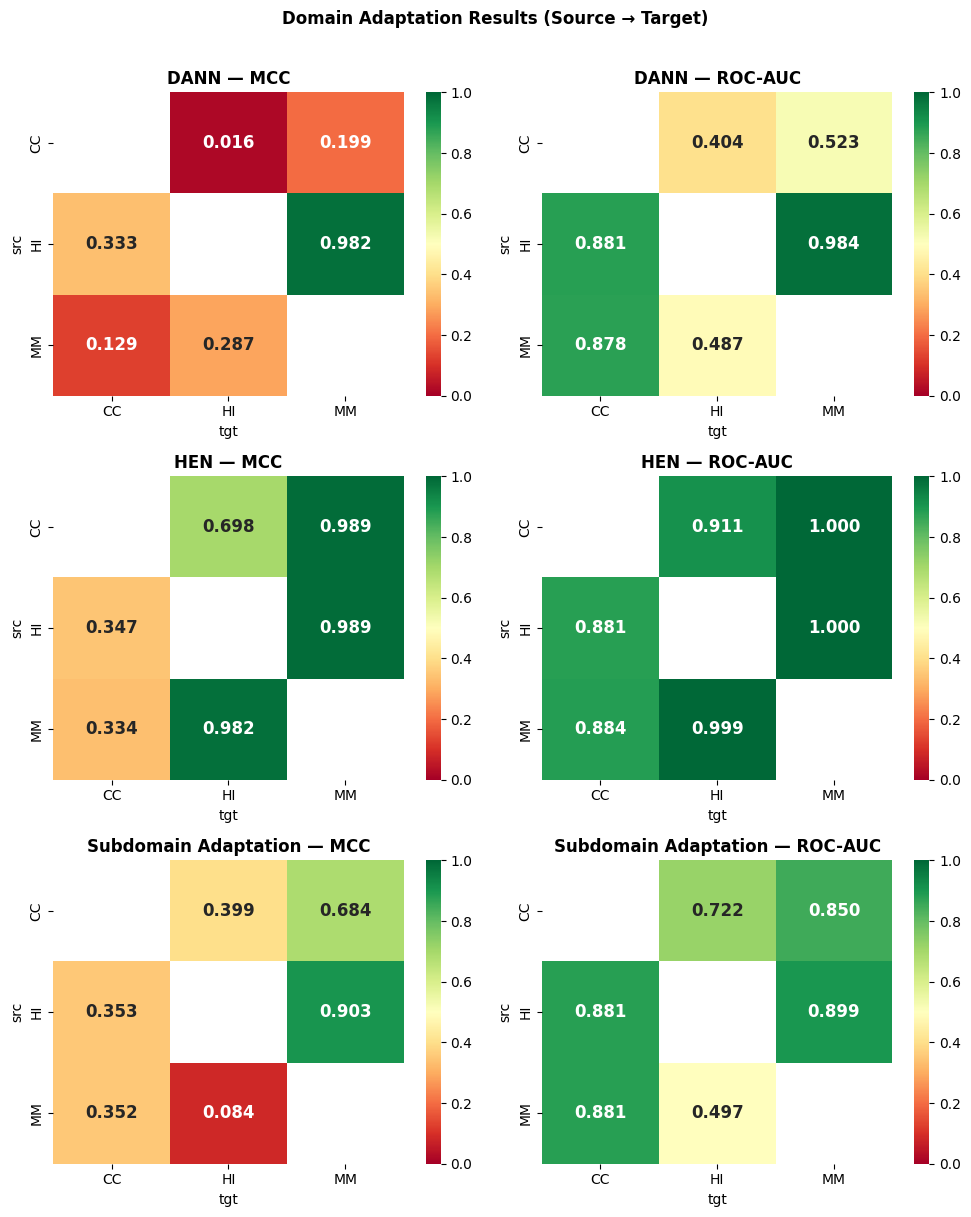

In [8]:
domain_abbrev = {'Credit Card':'CC','Mobile Money':'MM','Health Insurance':'HI'}
da_df['src'] = da_df['source'].map(domain_abbrev)
da_df['tgt'] = da_df['target'].map(domain_abbrev)

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
for row, method in enumerate(['DANN','HEN','Subdomain Adaptation']):
    for col, (metric, label) in enumerate([('mcc','MCC'),('roc_auc','ROC-AUC')]):
        ax    = axes[row, col]
        sub   = da_df[da_df['method'] == method]
        pivot = sub.pivot(index='src', columns='tgt', values=metric)
        import seaborn as sns
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
                    ax=ax, annot_kws={'size':12,'weight':'bold'})
        ax.set_title(f'{method}  -  {label}', fontweight='bold')

plt.suptitle('Domain Adaptation Results (Source -> Target)', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'domain_adaptation_heatmaps.png'), dpi=150, bbox_inches='tight')
plt.show()